Cell 0 — Source map

In [1]:
import pandas as pd
pd.set_option("display.max_colwidth", 60)

SOURCE_MAP = [
    ("Jan Preliminary 'AHW Comparison PUF + Prelim Inflation Factors'",
     "CBSA", False, "Area-level AHW (Jan preliminary) + wage-index inflation factors",
     "NB12 area cross-check ONLY (no CCN; the file we opened first by mistake)"),
    ("Final Rule 'Wage Index Data PUFs (S3 Part II and Occ Mix Data)' — RAW S-3",
     "Provider", True, "PROV + IIWG1..43 (wages) + IIHR1..43 (hours) + IVWG8..10 (wage-related costs)",
     "*** THIS NOTEBOOK *** confirmed=True source; needs net-wage formula to get totals"),
    ("Final Rule 'AHW + Occ Mix Factor by Provider' (computed summary)",
     "Provider", True, "Pre-computed AHW per CCN (occ-mix adj + unadj), totals already summed",
     "v1 shortcut (Decision 39) — simplest path if NB14 just needs AHW directly"),
    ("Final Rule 'AHW + Pre-Reclass Wage Index by CBSA'",
     "CBSA", False, "Area AHW + pre-reclass wage index per CBSA",
     "NB12 wage-index derivation cross-check"),
    ("Tables 2/3/4 (Wage Index Tables, Final Rule)",
     "Provider/CBSA", True, "Case-mix & wage-index *results* by CCN/CBSA",
     "Downstream result tables — NOT a wage source"),
]
source_map = pd.DataFrame(SOURCE_MAP, columns=["file","level","has_CCN","carries","use_for"])
print("CMS FY2026 wage-data source map\n" + "="*70)
for _, r in source_map.iterrows():
    print(f"\n• {r['file']}")
    print(f"    level={r['level']:9s} has_CCN={r['has_CCN']}")
    print(f"    carries : {r['carries']}")
    print(f"    use     : {r['use_for']}")

NATIONAL_AHW_UNADJ = 57.92    # FY2026 final rule, unadjusted national AHW
NATIONAL_AHW_OCCADJ = 57.86   # occupational-mix adjusted
print("\n" + "="*70)
print(f"National AHW (FY2026): unadjusted=${NATIONAL_AHW_UNADJ}  occ-mix-adj=${NATIONAL_AHW_OCCADJ}")

CMS FY2026 wage-data source map

• Jan Preliminary 'AHW Comparison PUF + Prelim Inflation Factors'
    level=CBSA      has_CCN=False
    carries : Area-level AHW (Jan preliminary) + wage-index inflation factors
    use     : NB12 area cross-check ONLY (no CCN; the file we opened first by mistake)

• Final Rule 'Wage Index Data PUFs (S3 Part II and Occ Mix Data)' — RAW S-3
    level=Provider  has_CCN=True
    carries : PROV + IIWG1..43 (wages) + IIHR1..43 (hours) + IVWG8..10 (wage-related costs)
    use     : *** THIS NOTEBOOK *** confirmed=True source; needs net-wage formula to get totals

• Final Rule 'AHW + Occ Mix Factor by Provider' (computed summary)
    level=Provider  has_CCN=True
    carries : Pre-computed AHW per CCN (occ-mix adj + unadj), totals already summed
    use     : v1 shortcut (Decision 39) — simplest path if NB14 just needs AHW directly

• Final Rule 'AHW + Pre-Reclass Wage Index by CBSA'
    level=CBSA      has_CCN=False
    carries : Area AHW + pre-reclass wage in

Cell 1 — Roster

In [2]:
ROSTER = [
    ("Baylor University Medical Center", "450021", "Nonprofit (church)", "Dallas",  ["19124"], True),
    ("Methodist Dallas Medical Center",  "450051", "Nonprofit",          "Dallas",  ["19124"], True),
    ("Parkland Health",                  "450015", "Government district", "Dallas",  ["19124"], False),
    ("Texas Health Presbyterian Plano",  "450771", "Nonprofit (private)", "Collin",  ["19124"], True),
    ("Medical City Alliance",            "670103", "HCA (for-profit)",    "Tarrant", ["23104","19124"], False),
]
hosp = pd.DataFrame(ROSTER, columns=["name","CCN","ownership","county","cbsa_candidates","has_990"])
hosp["ccn_provenance"] = "corroborated"   # not 'confirmed' until seen in the PUF itself
print(hosp[["name","CCN","ownership","county","has_990"]].to_string(index=False))
print("\nAnchors lacking a 990 (why avg_wage_fte — Decision 37):",
      ", ".join(hosp.loc[~hosp.has_990, "name"]))
print("MCA CBSA still open (feeds NB12):",
      hosp.loc[hosp.name=="Medical City Alliance","cbsa_candidates"].iloc[0])

                            name    CCN           ownership  county  has_990
Baylor University Medical Center 450021  Nonprofit (church)  Dallas     True
 Methodist Dallas Medical Center 450051           Nonprofit  Dallas     True
                 Parkland Health 450015 Government district  Dallas    False
 Texas Health Presbyterian Plano 450771 Nonprofit (private)  Collin     True
           Medical City Alliance 670103    HCA (for-profit) Tarrant    False

Anchors lacking a 990 (why avg_wage_fte — Decision 37): Parkland Health, Medical City Alliance
MCA CBSA still open (feeds NB12): ['23104', '19124']


Cell 2 — S-3 formula contract

In [3]:

S3_FORMULA = {
    "formula_confirmed": False,                       
    "wage_add_lines":  ["IIWG1"],                    
    "wage_sub_lines":  [],                            
    "wage_related":    ["IVWG8", "IVWG9", "IVWG10"],  
    "hour_add_lines":  ["IIHR1"],                     
    "hour_sub_lines":  [],                            
    "include_benefits_in_wages": True,                
}

def compute_s3_totals(row, formula=S3_FORMULA):
    """Apply the (placeholder) net-wage formula to one provider row -> (wages, hours)."""
    g = lambda c: float(row.get(c, 0) or 0)
    wages = sum(g(c) for c in formula["wage_add_lines"]) - sum(g(c) for c in formula["wage_sub_lines"])
    if formula["include_benefits_in_wages"]:
        wages += sum(g(c) for c in formula["wage_related"])
    hours = sum(g(c) for c in formula["hour_add_lines"]) - sum(g(c) for c in formula["hour_sub_lines"])
    return wages, hours

print("S3_FORMULA loaded. formula_confirmed =", S3_FORMULA["formula_confirmed"])
print("⚠️  Line membership is PLACEHOLDER — verify against the PUF layout tab before trusting any AHW.")

S3_FORMULA loaded. formula_confirmed = False
⚠️  Line membership is PLACEHOLDER — verify against the PUF layout tab before trusting any AHW.


Cell 3 — Synthetic smoke test

In [4]:
import numpy as np
rng = np.random.default_rng(20260623)

USE_SYNTHETIC = True   

def make_synthetic_s3(hosp_df):
    rows = []
    for _, h in hosp_df.iterrows():
        paid_hours = rng.integers(2_000_000, 9_000_000)
        base_wage  = rng.uniform(40, 52)                     
        salaries   = base_wage * paid_hours * rng.uniform(0.85, 0.95)
        benefits   = salaries * rng.uniform(0.18, 0.28)
        rows.append({"PROV": h["CCN"], "NAME": "SYN_"+h["name"],
                     "IIWG1": round(salaries,0), "IIHR1": int(paid_hours),
                     "IVWG8": round(benefits*0.5,0), "IVWG9": round(benefits*0.3,0),
                     "IVWG10": round(benefits*0.2,0)})
    return pd.DataFrame(rows)

WATERMARK = "[SYNTHETIC DATA]" if USE_SYNTHETIC else ""
raw_s3 = make_synthetic_s3(hosp) if USE_SYNTHETIC else pd.DataFrame()
print(f"raw_s3 source: {'SYNTHETIC' if USE_SYNTHETIC else 'REAL'}   watermark={WATERMARK or '(none)'}")
print(raw_s3[["PROV","NAME","IIWG1","IIHR1"]].to_string(index=False))

raw_s3 source: SYNTHETIC   watermark=[SYNTHETIC DATA]
  PROV                                 NAME       IIWG1   IIHR1
450021 SYN_Baylor University Medical Center 256789046.0 6668049
450051  SYN_Methodist Dallas Medical Center 239220590.0 6215771
450015                  SYN_Parkland Health 207207483.0 4684005
450771  SYN_Texas Health Presbyterian Plano 259897621.0 5605587
670103            SYN_Medical City Alliance 278779319.0 6280688


Cell R — Real-data wiring

In [5]:

REAL_S3_RAW = {}

REAL_S3_TOTALS = {}

def build_totals(hosp_df, raw_synth, formula=S3_FORMULA):
    out, prov = {}, {}
    for ccn in hosp_df["CCN"]:
        if ccn in REAL_S3_TOTALS:
            out[ccn] = tuple(REAL_S3_TOTALS[ccn]); prov[ccn] = "real_totals"
        elif ccn in REAL_S3_RAW:
            out[ccn] = compute_s3_totals(REAL_S3_RAW[ccn], formula); prov[ccn] = "real_raw"
        elif USE_SYNTHETIC and not raw_synth.empty:
            r = raw_synth.loc[raw_synth.PROV==ccn].iloc[0]
            out[ccn] = compute_s3_totals(r, formula); prov[ccn] = "synthetic"
        else:
            out[ccn] = (float("nan"), float("nan")); prov[ccn] = "empty"
    return out, prov

totals, provenance = build_totals(hosp, raw_s3)
n_real = sum(1 for p in provenance.values() if p.startswith("real"))
if   n_real == len(hosp): WM = ""
elif n_real == 0:         WM = "[SYNTHETIC DATA]" if USE_SYNTHETIC else "[NO REAL DATA YET]"
else:                     WM = "[PARTIAL REAL DATA]"
print(f"real CCNs filled: {n_real}/{len(hosp)}   watermark = {WM or '(clean)'}")
for ccn,(w,hh) in totals.items():
    print(f"  {ccn}: wages={w:,.0f}  hours={hh:,.0f}  [{provenance[ccn]}]" if w==w
          else f"  {ccn}: (empty)  [{provenance[ccn]}]")

real CCNs filled: 0/5   watermark = [SYNTHETIC DATA]
  450021: wages=313,114,855  hours=6,668,049  [synthetic]
  450051: wages=289,108,254  hours=6,215,771  [synthetic]
  450015: wages=263,697,007  hours=4,684,005  [synthetic]
  450771: wages=315,761,472  hours=5,605,587  [synthetic]
  670103: wages=340,776,519  hours=6,280,688  [synthetic]


Cell S — Benchmark sensitivity

In [6]:
BLS_DFW = {"practitioner": 49.10, "all_occupations": 32.89, "support": 17.67}  # NB14, May 2024

ahw = {ccn: (w/hh if (hh and hh==hh and w==w) else float("nan")) for ccn,(w,hh) in totals.items()}
res = hosp[["name","CCN"]].copy()
res["AHW"] = res["CCN"].map(ahw)
for k,v in BLS_DFW.items():
    res[f"x_{k}"] = res["AHW"]/v
print(f"AHW vs BLS DFW benchmarks   {WM}".strip())
print(res.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))
print("\nDenominator swing (Decision 38 pending):")
for k,v in BLS_DFW.items():
    m = res[f"x_{k}"].mean()
    print(f"  vs {k:16s} (${v}): mean multiple ≈ {m:,.2f}×" if m==m else f"  vs {k}: (no data)")

AHW vs BLS DFW benchmarks   [SYNTHETIC DATA]
                            name    CCN   AHW  x_practitioner  x_all_occupations  x_support
Baylor University Medical Center 450021 46.96            0.96               1.43       2.66
 Methodist Dallas Medical Center 450051 46.51            0.95               1.41       2.63
                 Parkland Health 450015 56.30            1.15               1.71       3.19
 Texas Health Presbyterian Plano 450771 56.33            1.15               1.71       3.19
           Medical City Alliance 670103 54.26            1.11               1.65       3.07

Denominator swing (Decision 38 pending):
  vs practitioner     ($49.1): mean multiple ≈ 1.06×
  vs all_occupations  ($32.89): mean multiple ≈ 1.58×
  vs support          ($17.67): mean multiple ≈ 2.95×


Cell V — Visualization

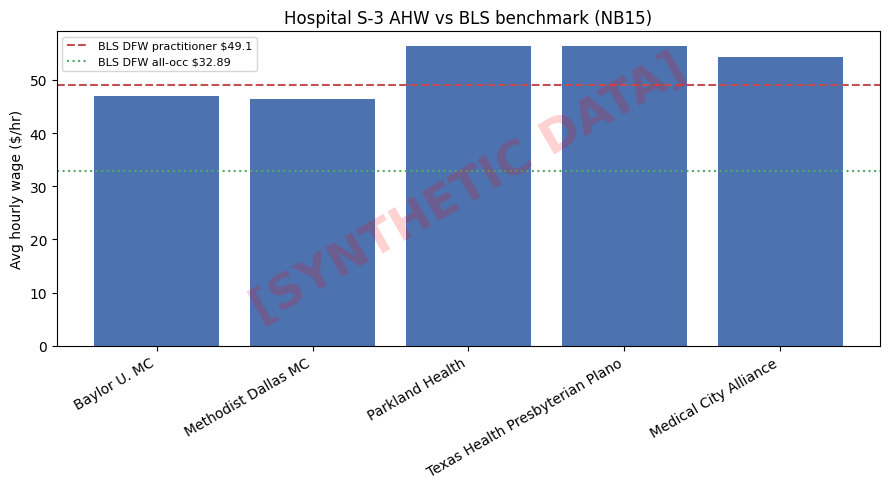

render watermark: [SYNTHETIC DATA]


In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9,5))
vals = res["AHW"].values
labels = [n.replace("Medical Center","MC").replace("University","U.") for n in res["name"]]
if pd.notna(vals).any():
    ax.bar(range(len(res)), vals, color="#4C72B0")
    ax.axhline(BLS_DFW["practitioner"], ls="--", color="#C44E52",
               label=f"BLS DFW practitioner ${BLS_DFW['practitioner']}")
    ax.axhline(BLS_DFW["all_occupations"], ls=":", color="#55A868",
               label=f"BLS DFW all-occ ${BLS_DFW['all_occupations']}")
    ax.set_xticks(range(len(res))); ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("Avg hourly wage ($/hr)")
    ax.set_title("Hospital S-3 AHW vs BLS benchmark (NB15)")
    ax.legend(fontsize=8)
    if WM:
        ax.text(0.5,0.5, WM, transform=ax.transAxes, fontsize=34, color="red",
                alpha=0.18, ha="center", va="center", rotation=30, fontweight="bold")
else:
    ax.text(0.5,0.5,"[NO REAL DATA YET]", transform=ax.transAxes, fontsize=20,
            ha="center", va="center", color="gray"); ax.set_axis_off()
plt.tight_layout(); plt.show()
print("render watermark:", WM or "(clean — safe to use)")

Cell F — Findings / handoff

In [8]:
print("=== NB15 → NB14 handoff: REAL_S3 candidate ===")
print(f"provenance: {n_real}/{len(hosp)} real   watermark: {WM or '(clean)'}")
print(f"S3 formula confirmed: {S3_FORMULA['formula_confirmed']}")
print("REAL_S3 = {")
for ccn,(w,hh) in totals.items():
    cell = f'({w:,.0f}, {hh:,.0f})' if w==w else 'None'
    print(f'    "{ccn}": {cell},   # {provenance[ccn]}')
print("}")
if not S3_FORMULA["formula_confirmed"]:
    print("\n⚠️  DO NOT paste into NB14 yet — formula is placeholder/unverified.")

=== NB15 → NB14 handoff: REAL_S3 candidate ===
provenance: 0/5 real   watermark: [SYNTHETIC DATA]
S3 formula confirmed: False
REAL_S3 = {
    "450021": (313,114,855, 6,668,049),   # synthetic
    "450051": (289,108,254, 6,215,771),   # synthetic
    "450015": (263,697,007, 4,684,005),   # synthetic
    "450771": (315,761,472, 5,605,587),   # synthetic
    "670103": (340,776,519, 6,280,688),   # synthetic
}

⚠️  DO NOT paste into NB14 yet — formula is placeholder/unverified.


Cell I — Integrity guards 

In [9]:
def integrity_check():
    errs = []
    if WM == "" and n_real != len(hosp):
        errs.append("clean watermark but not all CCNs real")
    for ccn,a in ahw.items():
        if provenance[ccn].startswith("real") and not (a==a and a>0):
            errs.append(f"{ccn}: real row but AHW not positive-finite")
    if S3_FORMULA["formula_confirmed"] not in (True, False):
        errs.append("formula_confirmed not boolean")
    if not S3_FORMULA["formula_confirmed"] and any(p=="real_raw" for p in provenance.values()):
        errs.append("raw real rows decoded with UNVERIFIED formula — block until confirmed")
    return errs

problems = integrity_check()
print("Integrity:", "OK" if not problems else "FAIL")
for p in problems: print("  -", p)
assert not problems, "integrity failed"

Integrity: OK
